In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [4]:
df=pd.read_csv(r'D:\Python\ML\Projects\Linear\Salary Prediction\Salary_Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df.dtypes

Age                    float64
Gender                     str
Education Level            str
Job Title                  str
Years of Experience    float64
Salary                 float64
dtype: object

In [6]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [7]:
df=df.dropna()

In [8]:
df_encoded=pd.get_dummies(df,columns=['Gender','Education Level','Job Title'],drop_first=True).astype(int)
df_encoded.head()

,Age,Years of Experience,Salary,Gender_Male,Gender_Other,Education Level_Bachelor's Degree,Education Level_High School,Education Level_Master's,Education Level_Master's Degree,Education Level_PhD,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32,5,90000,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,28,3,65000,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,45,15,150000,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,36,7,60000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52,20,200000,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df_encoded['Gender_Other'].value_counts()

Gender_Other
0    6684
1      14
Name: count, dtype: int64

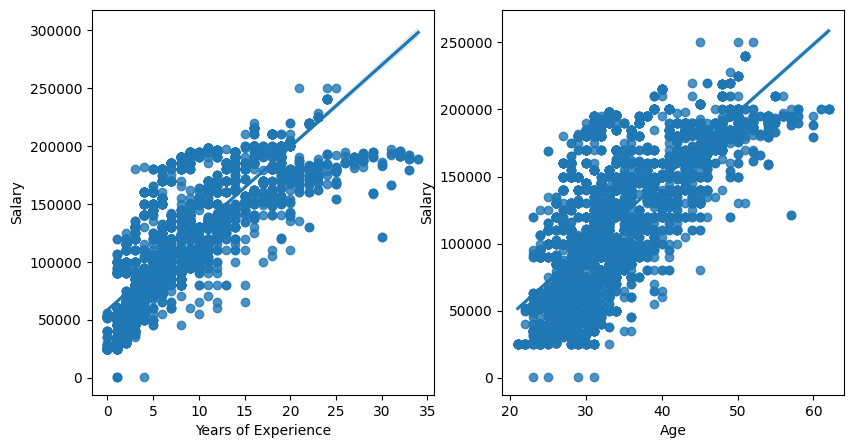

In [10]:
plt.figure(figsize=(15,5))
sns.regplot(x='Years of Experience',y='Salary',data=df_encoded,ax=plt.subplot(1,3,1))
sns.regplot(x='Age',y='Salary',data=df_encoded,ax=plt.subplot(1,3,2))
plt.show()


In [11]:
df_encoded[['Years of Experience', 'Age', 'Salary']].describe()

,Years of Experience,Age,Salary
count,6698.000000,6698.000000,6698.000000
mean,8.094207,33.623022,115329.253061
std,6.061399,7.615784,52789.792507
min,0.000000,21.000000,350.000000
25%,3.000000,28.000000,70000.000000
50%,7.000000,32.000000,115000.000000
75%,12.000000,38.000000,160000.000000
max,34.000000,62.000000,250000.000000


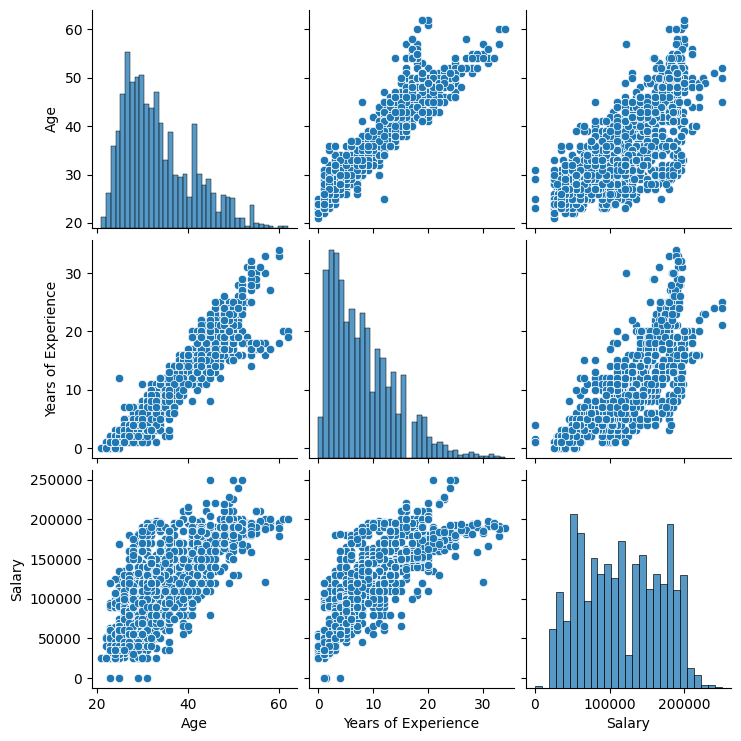

In [12]:
sns.pairplot(df)
plt.show()

In [13]:
X=df_encoded.drop('Salary',axis=1)
y=df_encoded['Salary']
X.head()

,Age,Years of Experience,Gender_Male,Gender_Other,Education Level_Bachelor's Degree,Education Level_High School,Education Level_Master's,Education Level_Master's Degree,Education Level_PhD,Education Level_phD,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32,5,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,28,3,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,45,15,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,36,7,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52,20,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((5358, 200), (1340, 200), (5358,), (1340,))

In [15]:
scaler=StandardScaler()
X_scaled_train=scaler.fit_transform(X_train)
X_scaled_test=scaler.transform(X_test)

In [16]:
model=LinearRegression()
model.fit(X_scaled_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_scaled_train, y_train,scoring='neg_mean_squared_error', cv=5)
print(f'Cross-validation scores: {cv_scores.mean()}')

Cross-validation scores: -340329679.6048226


In [18]:
models={'linear_regression':LinearRegression(),'Ridge_regression':Ridge(alpha=1),'Lasso_regression':Lasso(alpha=0.1)}
for name,model in models.items():
    model.fit(X_scaled_train,y_train)
    y_pred=model.predict(X_scaled_test)
    mse=mean_squared_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)
    print(f'{name} - MSE: {mse:.2f}, R²: {r2:.2f}, MAE: {mae:.2f}')


linear_regression - MSE: 352145541.73, R²: 0.88, MAE: 13156.80
Ridge_regression - MSE: 364460857.36, R²: 0.87, MAE: 13362.15
Lasso_regression - MSE: 379623279.82, R²: 0.87, MAE: 13534.91


c:\Users\haris\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.768e+11, tolerance: 1.484e+09
  model = cd_fast.enet_coordinate_descent(


In [19]:
y_pred=model.predict(X_scaled_test)

In [20]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
R2=r2_score(y_test,y_pred)
print(f"MAE:{mae}\nMSE:{mse}\nRMSE:{rmse}\nR2:{R2}")

MAE:13534.912318764244
MSE:379623279.8172032
RMSE:19483.9236248042
R2:0.8668670155432054


In [21]:
coeff=pd.DataFrame({'Feature':X.columns,'Coefficient':model.coef_,'Intercept':model.intercept_})
coeff

,Feature,Coefficient,Intercept
0,Age,8137.751682,115485.334267
1,Years of Experience,24474.447616,115485.334267
2,Gender_Male,445.485932,115485.334267
3,Gender_Other,-856.334136,115485.334267
4,Education Level_Bachelor's Degree,-24677.559093,115485.334267
...,...,...,...
195,Job Title_UX Designer,-485.655247,115485.334267
196,Job Title_UX Researcher,-421.456046,115485.334267
197,Job Title_VP of Finance,173.219159,115485.334267
198,Job Title_VP of Operations,36.616869,115485.334267


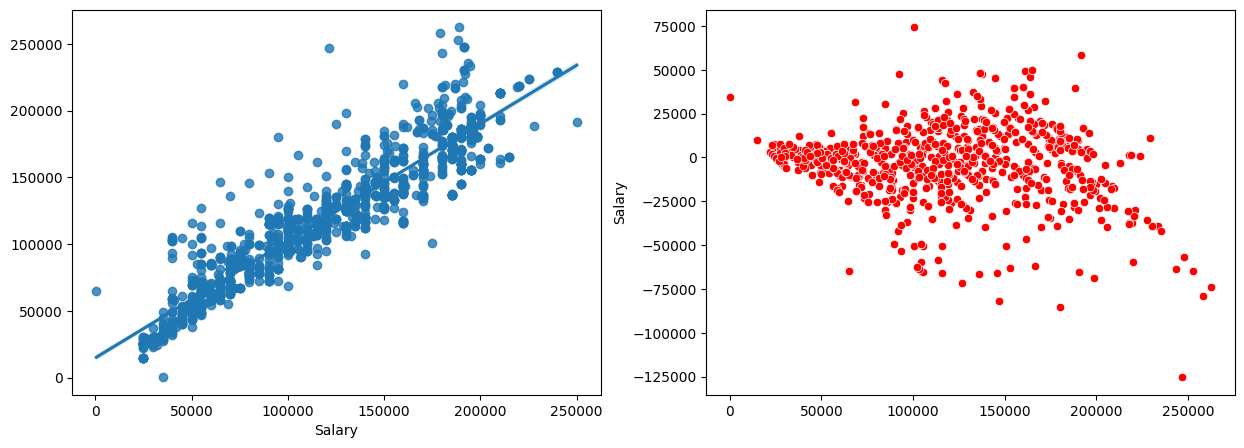

In [22]:
plt.figure(figsize=(15,5))
sns.regplot(x=y_test,y=y_pred,ax=plt.subplot(1,2,1))
sns.scatterplot(x=y_pred,y=y_test-y_pred,ax=plt.subplot(1,2,2),color='red')
plt.show()

Text(0.5, 1.0, 'Residual Distribution')

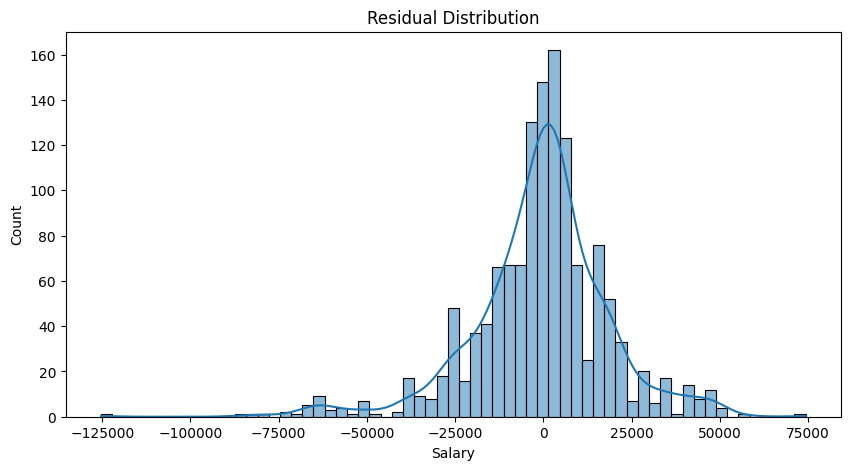

In [23]:
residual=y_test-y_pred
plt.figure(figsize=(10,5))
sns.histplot(residual,kde=True)
plt.title('Residual Distribution')